# Predicción del precio de automóviles mediante Machine Learning

**Curso:** Data Science II  
**Proyecto final:** Entrenamiento y optimización de modelos de Machine Learning  
**Dataset:** Automobile Dataset  
**Objetivo:** Analizar las características de distintos automóviles y construir modelos predictivos para estimar su precio.

## Abstracto, motivación y audiencia

El presente proyecto tiene como objetivo analizar un conjunto de datos de automóviles con características técnicas, comerciales y de riesgo asegurador, para construir modelos de Machine Learning capaces de predecir el precio de un vehículo.

La motivación del análisis surge de la importancia que tiene la estimación de precios dentro de la industria automotriz. Una predicción confiable puede aportar valor a concesionarias, aseguradoras, plataformas de venta de autos usados y áreas de pricing, permitiendo tomar decisiones más informadas sobre valuación, segmentación y comparación de vehículos.

La audiencia principal de este análisis está compuesta por equipos de negocio, analistas de datos y responsables comerciales que buscan comprender qué variables influyen en el precio de un automóvil y cómo estas pueden utilizarse para estimar su valor.

## Pregunta de negocio y problema de Machine Learning

La pregunta principal que se busca responder es:

**¿Qué características técnicas y comerciales de un automóvil permiten predecir mejor su precio?**

Dado que la variable objetivo `price` representa un valor numérico continuo, el problema se modela como una tarea de **regresión supervisada**.

El objetivo del modelo será estimar el precio de un automóvil a partir de variables como marca, tipo de combustible, peso, tamaño del motor, potencia, consumo y otras características del vehículo.

## Descripción del dataset

El dataset utilizado contiene información técnica, comercial y aseguradora de distintos automóviles. Cada registro representa un vehículo y sus características asociadas, como marca, tipo de combustible, dimensiones, peso, tamaño del motor, potencia, consumo y precio.

El conjunto cuenta con **205 registros** y **26 variables**. La variable objetivo seleccionada para el proyecto es `price`, ya que se busca construir un modelo capaz de estimar el precio de un automóvil a partir del resto de sus atributos.

Además de variables técnicas, el dataset incluye información vinculada al riesgo asegurador, como `symboling` y `normalized-losses`. Los valores faltantes se encuentran representados originalmente con el carácter `"?"`, por lo que fue necesario tratarlos durante la etapa de limpieza.

| Característica | Descripción |
|---|---|
| Cantidad de registros | 205 |
| Cantidad de variables | 26 |
| Variable objetivo | `price` |
| Tipo de problema | Regresión supervisada |
| Valores faltantes | Representados como `"?"` |
| Dominio | Industria automotriz |

Entre las variables más relevantes se encuentran:

- `make`: marca del automóvil.
- `body-style`: tipo de carrocería.
- `engine-size`: tamaño del motor.
- `horsepower`: potencia.
- `curb-weight`: peso del vehículo.
- `city-mpg` y `highway-mpg`: eficiencia de combustible.
- `price`: precio del automóvil.

## Carga de librerías y datos

In [1]:
import os
import pandas as pd

possible_paths = [
    "Automobile_data.csv",
    "data/Automobile_data.csv",
    "../data/Automobile_data.csv"
]

data_path = None

for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    from google.colab import files
    uploaded = files.upload()
    data_path = list(uploaded.keys())[0]

df = pd.read_csv(data_path)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [2]:
import pandas as pd

df = pd.read_csv("Automobile_data.csv")
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [3]:
# Librerías principales
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuración visual
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [4]:
df.shape

(205, 26)

In [5]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
symboling,205.0,NaN,NaN,NaN,0.834146,1.245307,-2.0,0.0,1.0,2.0,3.0
normalized-losses,205,52,?,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
make,205,22,toyota,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel-type,205,2,gas,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aspiration,205,2,std,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num-of-doors,205,3,four,114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body-style,205,5,sedan,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drive-wheels,205,3,fwd,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine-location,205,2,front,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wheel-base,205.0,NaN,NaN,NaN,98.756585,6.021776,86.6,94.5,97.0,102.4,120.9


In [8]:
df.isnull().sum()

,0
symboling,0
normalized-losses,0
make,0
fuel-type,0
aspiration,0
num-of-doors,0
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0


*El dataset utiliza el carácter `"?"` para representar valores faltantes. Por este motivo, se reemplazaron dichos valores por `NaN`, permitiendo aplicar correctamente técnicas de imputación y análisis de valores nulos.*

## Limpieza de datos

In [9]:
#  Limpieza de "?"
df = df.replace("?", np.nan)

missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

,0
normalized-losses,41
stroke,4
price,4
bore,4
horsepower,2
peak-rpm,2
num-of-doors,2


In [10]:
#Conversion de tipos
numeric_cols_to_convert = [
    "normalized-losses",
    "bore",
    "stroke",
    "horsepower",
    "peak-rpm",
    "price"
]

for col in numeric_cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [11]:
 # Eliminar filas sin target
df = df.dropna(subset=["price"])

df.shape

(201, 26)

Se eliminaron los registros sin valor en la variable objetivo `price`, ya que no pueden utilizarse para entrenar ni evaluar un modelo supervisado de regresión.

## EDA

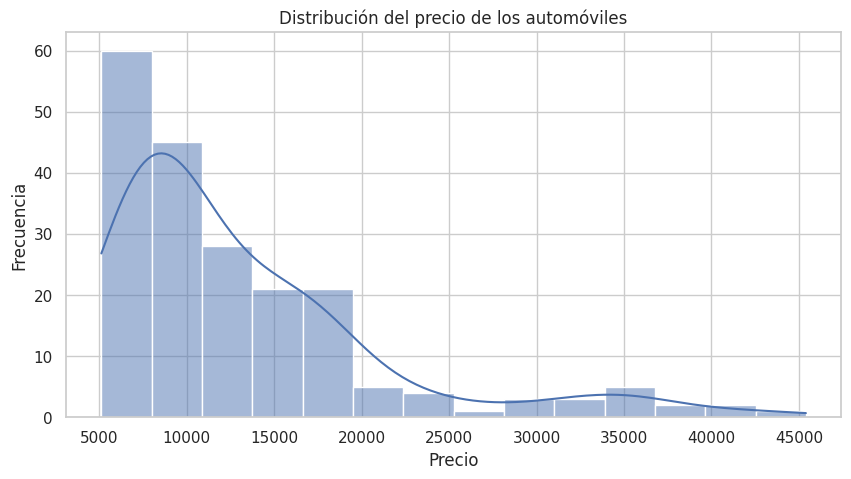

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(df["price"], kde=True)
plt.title("Distribución del precio de los automóviles")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

La variable objetivo `price` muestra una distribución asimétrica hacia la derecha. La mayoría de los vehículos se concentra en valores bajos y medios, mientras que unos pocos autos presentan precios significativamente superiores.

Esta asimetría sugiere la posible presencia de outliers o vehículos de gama alta, los cuales pueden afectar el desempeño de algunos modelos de regresión.

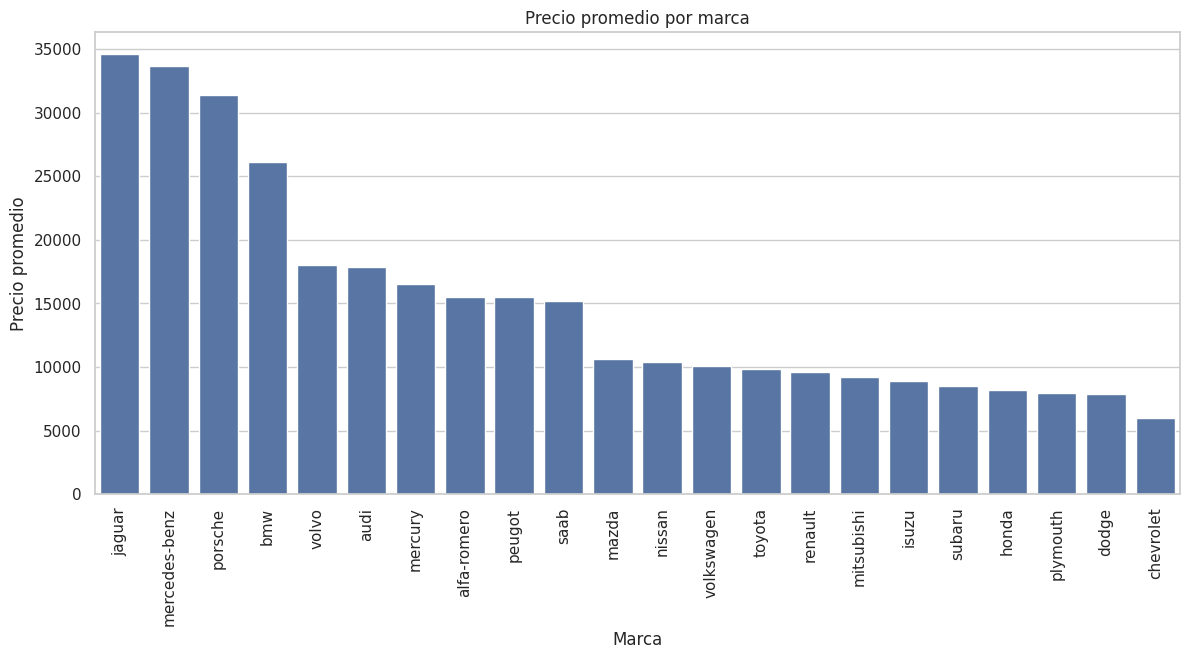

In [13]:
plt.figure(figsize=(14,6))
avg_price_make = df.groupby("make")["price"].mean().sort_values(ascending=False)
sns.barplot(x=avg_price_make.index, y=avg_price_make.values)
plt.xticks(rotation=90)
plt.title("Precio promedio por marca")
plt.xlabel("Marca")
plt.ylabel("Precio promedio")
plt.show()

El precio promedio varía de forma significativa según la marca del automóvil. Se observa que marcas como `jaguar`, `mercedes-benz`, `porsche` y `bmw` presentan los valores promedio más altos, mientras que marcas como `chevrolet`, `dodge`, `plymouth` y `honda` se ubican en los rangos más bajos.

Esta diferencia sugiere que la marca puede ser una variable relevante para predecir el precio, ya que probablemente captura factores asociados al posicionamiento comercial, gama del vehículo, prestaciones y percepción de valor. Sin embargo, dado que algunas marcas pueden tener pocos registros en el dataset, este resultado debe interpretarse con cautela y complementarse con otras variables técnicas como potencia, tamaño del motor, peso y dimensiones.

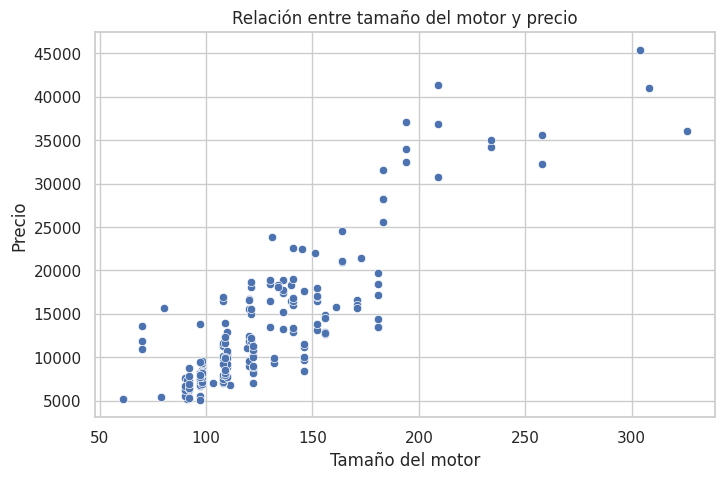

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="engine-size", y="price")
plt.title("Relación entre tamaño del motor y precio")
plt.xlabel("Tamaño del motor")
plt.ylabel("Precio")
plt.show()

Se observa una tendencia positiva entre `engine-size` y `price`: los vehículos con motores más grandes tienden a presentar precios más altos. Esto sugiere que el tamaño del motor es una variable relevante para explicar el valor del automóvil.

Sin embargo, la dispersión de puntos indica que el precio no depende únicamente de esta característica. Para obtener mejores predicciones será necesario combinarla con otras variables técnicas y comerciales, como potencia, peso, marca y tipo de tracción.

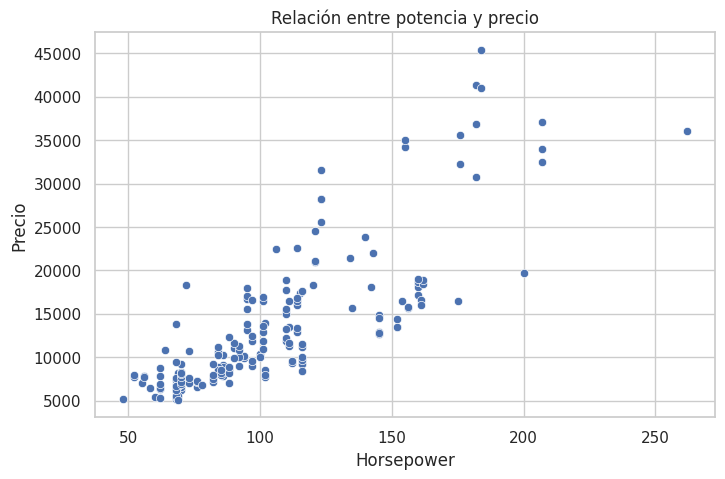

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="horsepower", y="price")
plt.title("Relación entre potencia y precio")
plt.xlabel("Horsepower")
plt.ylabel("Precio")
plt.show()

Se observa una tendencia positiva entre `horsepower` y `price`, lo que indica que los automóviles con mayor potencia suelen tener precios más altos. Aun así, la dispersión de los puntos muestra que la potencia no explica por completo el precio, ya que autos con valores similares de `horsepower` pueden presentar diferencias importantes de valor.

Esto sugiere que `horsepower` será una variable predictiva relevante, pero deberá combinarse con otros atributos técnicos y comerciales. Además, la presencia de algunos vehículos de alta potencia y alto precio refuerza la necesidad de evaluar modelos no lineales y métricas robustas frente a errores grandes.

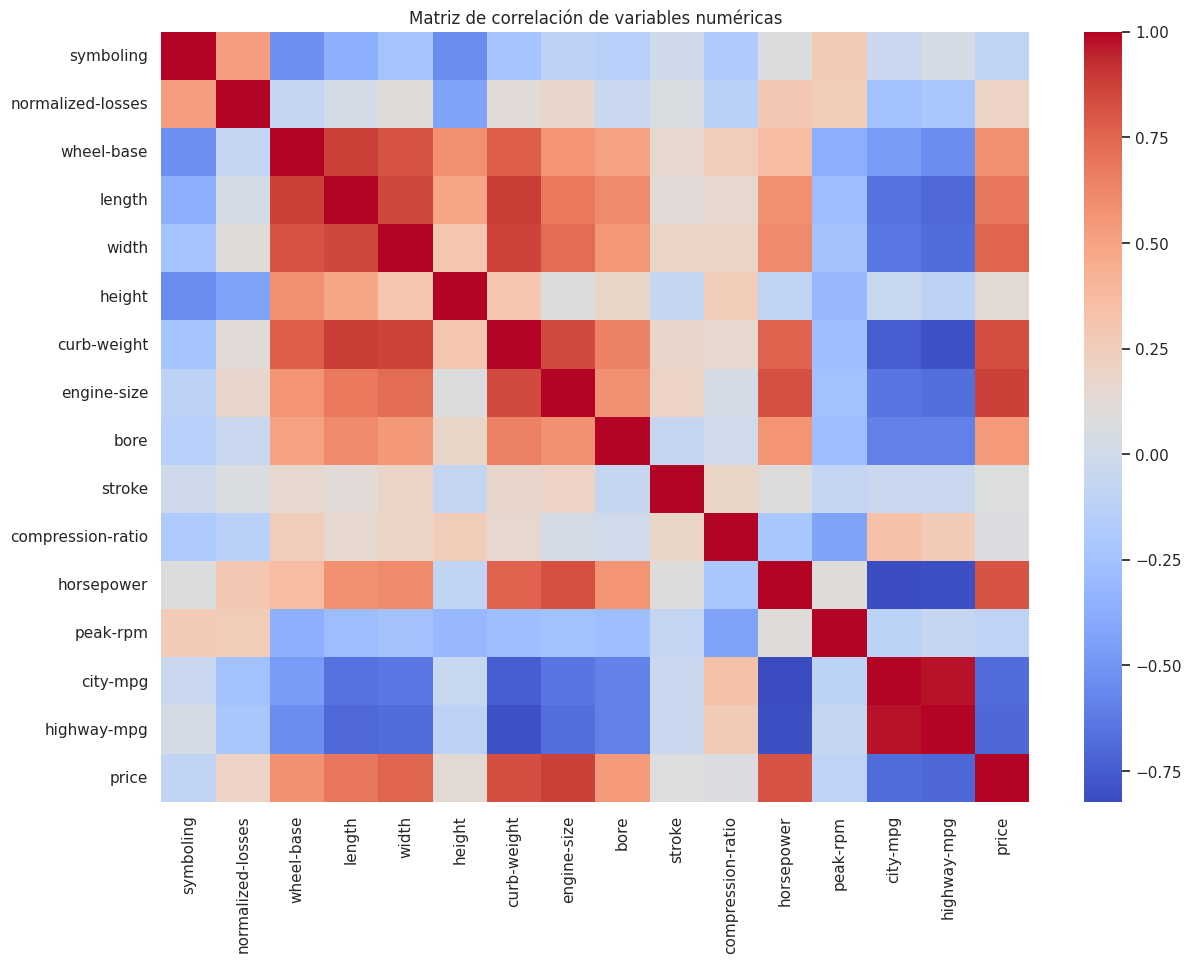

In [16]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Matriz de correlación de variables numéricas")
plt.show()

In [17]:
correlations = numeric_df.corr()["price"].sort_values(ascending=False)
correlations

,price
price,1.000000
engine-size,0.872335
curb-weight,0.834415
horsepower,0.810533
width,0.751265
length,0.690628
wheel-base,0.584642
bore,0.543436
normalized-losses,0.203254
height,0.135486


La matriz de correlación y el ranking de correlaciones muestran que `price` presenta una asociación positiva fuerte con variables técnicas del vehículo. Las correlaciones más altas se observan con `engine-size` (0.87), `curb-weight` (0.83), `horsepower` (0.81), `width` (0.75) y `length` (0.69). Esto indica que los autos más grandes, pesados y potentes tienden a tener precios más elevados.

Por otro lado, `city-mpg` (-0.69) y `highway-mpg` (-0.70) presentan una correlación negativa fuerte con el precio. Esto sugiere que los vehículos de mayor precio suelen tener menor eficiencia de combustible, probablemente por estar asociados a motores más grandes y mayor potencia.

También se observa que varias variables explicativas están correlacionadas entre sí, como dimensiones del vehículo, peso, tamaño del motor y consumo.

## Ingeniería de atributos

A partir del análisis exploratorio, se identificaron variables técnicas relevantes para explicar el precio de los automóviles. Con el objetivo de enriquecer el dataset, se crearon nuevas variables derivadas a partir de características existentes.

Estas nuevas variables buscan representar relaciones de negocio y performance del vehículo, como eficiencia, relación potencia-peso y volumen aproximado.

In [18]:
df["mpg_average"] = (df["city-mpg"] + df["highway-mpg"]) / 2

df["power_to_weight"] = df["horsepower"] / df["curb-weight"]

df["engine_efficiency"] = df["horsepower"] / df["engine-size"]

df["car_volume"] = df["length"] * df["width"] * df["height"]

df[["mpg_average", "power_to_weight", "engine_efficiency", "car_volume"]].head()

,mpg_average,power_to_weight,engine_efficiency,car_volume
0,24.0,0.043564,0.853846,528019.904
1,24.0,0.043564,0.853846,528019.904
2,22.5,0.054552,1.013158,587592.640
3,27.0,0.043646,0.935780,634816.956
4,20.0,0.040722,0.845588,636734.832


Se crearon las siguientes variables:

- `mpg_average`: promedio entre rendimiento en ciudad y ruta.
- `power_to_weight`: relación entre potencia y peso del vehículo.
- `engine_efficiency`: relación entre potencia y tamaño del motor.
- `car_volume`: aproximación del volumen del vehículo a partir de sus dimensiones.

Estas variables pueden aportar información adicional al modelo, especialmente porque combinan atributos técnicos que individualmente ya mostraban relación con el precio.

## Preparación de los datos para Machine Learning

Para entrenar los modelos, se separó la variable objetivo `price` del resto de las variables predictoras.  
Dado que `price` es una variable numérica continua, el problema se aborda como una tarea de regresión supervisada.

In [19]:
X = df.drop("price", axis=1)
y = df["price"]

X.shape, y.shape

((201, 29), (201,))

In [20]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
Index(['symboling', 'normalized-losses', 'wheel-base', 'length', 'width',
       'height', 'curb-weight', 'engine-size', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'mpg_average', 'power_to_weight', 'engine_efficiency',
       'car_volume'],
      dtype='object')

Variables categóricas:
Index(['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style',
       'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders',
       'fuel-system'],
      dtype='object')


El dataset contiene variables numéricas y categóricas, por lo que será necesario aplicar distintos tratamientos antes del entrenamiento de los modelos.

Las variables numéricas incluyen características técnicas del vehículo, como peso, dimensiones, tamaño del motor, potencia, consumo y variables creadas mediante ingeniería de atributos. Estas variables serán imputadas y estandarizadas.

Las variables categóricas incluyen información descriptiva del automóvil, como marca, tipo de combustible, carrocería, sistema de tracción, ubicación del motor y tipo de motor. Estas variables deberán transformarse mediante codificación para que puedan ser utilizadas por los modelos de Machine Learning.

Esta separación permite construir un flujo de preprocesamiento más robusto, aplicando transformaciones específicas según el tipo de dato y evitando tratar todas las variables de la misma forma.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de test:", X_test.shape)

Tamaño de entrenamiento: (160, 29)
Tamaño de test: (41, 29)


## División del dataset en entrenamiento y testeo

Para evaluar el desempeño de los modelos, se dividió el dataset en dos subconjuntos:

- **Conjunto de entrenamiento:** utilizado para ajustar los modelos.
- **Conjunto de testeo:** utilizado para evaluar el rendimiento sobre datos no vistos.

Se utilizó una proporción de **80% para entrenamiento** y **20% para testeo**, manteniendo una semilla fija mediante `random_state=42` para asegurar que los resultados sean reproducibles.

Luego de la división, el conjunto de entrenamiento quedó compuesto por **160 registros**, mientras que el conjunto de testeo quedó compuesto por **41 registros**.

In [22]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

Se construyó un pipeline de preprocesamiento para tratar de forma diferenciada las variables numéricas y categóricas.

Para las variables numéricas se aplicó imputación con la mediana y estandarización mediante `StandardScaler`.  
Para las variables categóricas se aplicó imputación con la moda y codificación `OneHotEncoder`.

El uso de pipelines permite mantener el flujo de trabajo ordenado y evita fuga de información, ya que las transformaciones se ajustan únicamente con los datos de entrenamiento.

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    return mae, rmse, r2

Para comparar los modelos se utilizaron tres métricas principales:

- **MAE:** error absoluto medio. Indica cuánto se equivoca el modelo en promedio.
- **RMSE:** raíz del error cuadrático medio. Penaliza con mayor fuerza los errores grandes.
- **R²:** proporción de la variabilidad del precio explicada por el modelo.

Estas métricas permiten evaluar el desempeño desde distintas perspectivas.

## Entrenamiento y comparación inicial de modelos

Se entrenaron distintos modelos de regresión para comparar su desempeño inicial sobre el conjunto de testeo. Se incluyeron modelos lineales, modelos regularizados y modelos basados en árboles, con el objetivo de evaluar si el problema se ajusta mejor a relaciones lineales simples o a relaciones más complejas y no lineales.

En esta primera comparación, el modelo con mejor rendimiento fue **Gradient Boosting**, obteniendo el menor valor de **RMSE** y el mayor valor de **R²**. Esto indica que, para este dataset, los modelos basados en ensambles de árboles logran capturar mejor la relación entre las características del automóvil y su precio.

De todas formas, esta evaluación corresponde a una única partición de entrenamiento/testeo. Por ese motivo, en el siguiente paso se aplicará validación cruzada para obtener una medición más robusta y reducir la dependencia de una sola división de los datos.

In [24]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(max_iter=10000),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    mae, rmse, r2 = evaluate_model(pipeline, X_train, X_test, y_train, y_test)

    results.append({
        "Modelo": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values(by="RMSE")
results_df

,Modelo,MAE,RMSE,R2
5,Gradient Boosting,1554.631047,2443.985387,0.951179
3,Decision Tree,1829.695122,2849.080049,0.933654
4,Random Forest,1814.204711,2865.286915,0.932897
2,Lasso,1863.351532,2898.855029,0.931315
0,Linear Regression,1860.802757,2945.646399,0.929080
1,Ridge,1831.783157,2946.778956,0.929025


A partir de esta comparación inicial, se observa que los modelos basados en árboles superan a los modelos lineales. Esto sugiere que la relación entre las variables explicativas y el precio no es completamente lineal, sino que probablemente existen interacciones y patrones más complejos entre atributos como potencia, peso, tamaño del motor, marca y tipo de vehículo.

## Comparación visual de modelos

El gráfico compara el rendimiento de los modelos utilizando **RMSE** como métrica principal. Dado que el RMSE mide el error promedio penalizando con mayor fuerza los errores grandes, un valor más bajo indica un mejor desempeño predictivo.


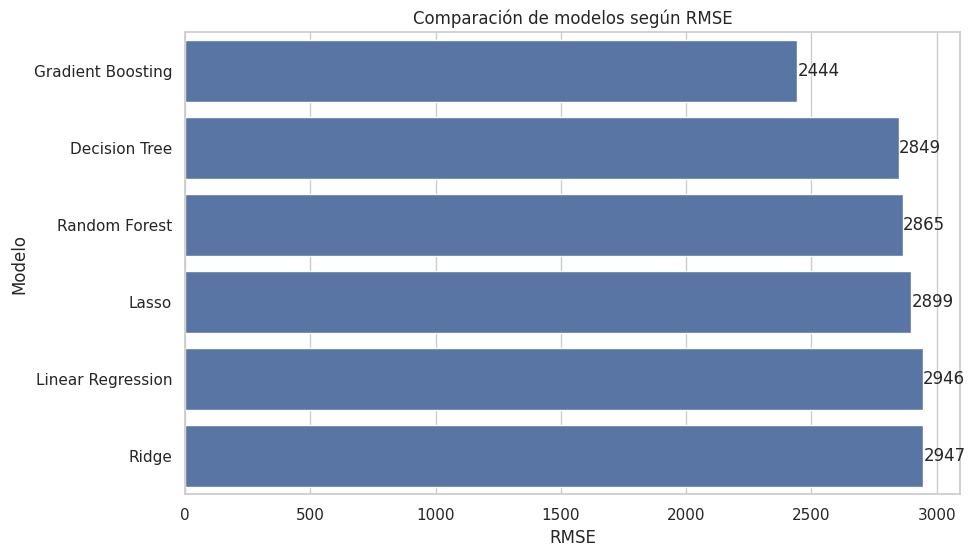

In [25]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=results_df,
    x="RMSE",
    y="Modelo"
)

plt.title("Comparación de modelos según RMSE")
plt.xlabel("RMSE")
plt.ylabel("Modelo")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.show()

En esta comparación inicial, **Gradient Boosting** obtuvo el menor RMSE, por lo que presenta el mejor rendimiento sobre el conjunto de testeo. Los modelos lineales y regularizados muestran errores más altos, lo que sugiere que el problema podría tener relaciones no lineales entre las variables explicativas y el precio.

Sin embargo, esta evaluación depende de una única división entre entrenamiento y testeo. Por eso, en el siguiente paso se utilizará validación cruzada para confirmar si este desempeño se mantiene de forma más estable.

## Comparación visual según R²

El gráfico muestra la comparación de los modelos utilizando **R²** como métrica de evaluación. Esta métrica indica qué proporción de la variabilidad del precio puede ser explicada por el modelo.

En este caso, **Gradient Boosting** obtuvo el mayor valor de R², superando al resto de los modelos evaluados. Esto refuerza lo observado en la comparación por RMSE: los modelos basados en árboles y ensambles presentan un mejor desempeño para este problema.

Los modelos lineales también obtienen valores de R² altos, pero quedan por debajo de los modelos más flexibles. Esto sugiere que, si bien existe una relación importante entre las variables disponibles y el precio, los modelos capaces de capturar relaciones no lineales logran representar mejor los patrones del dataset.

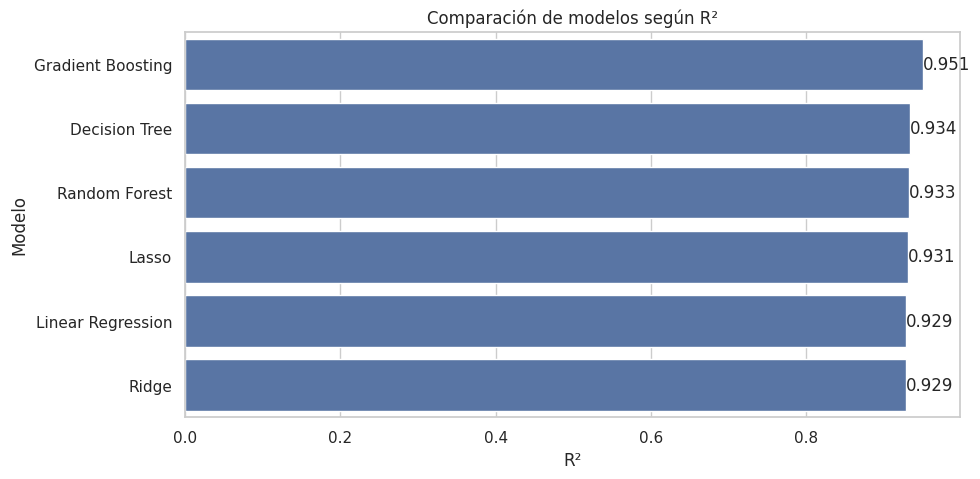

In [26]:
plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=results_df.sort_values(by="R2", ascending=False),
    x="R2",
    y="Modelo"
)

plt.title("Comparación de modelos según R²")
plt.xlabel("R²")
plt.ylabel("Modelo")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.show()

Aunque todos los modelos presentan un R² elevado, Gradient Boosting logra la mejor combinación entre bajo error absoluto y alta capacidad explicativa.

## Validación cruzada de modelos

Luego de realizar una primera comparación utilizando una única división entre entrenamiento y testeo, se aplicó validación cruzada para obtener una evaluación más robusta del desempeño de los modelos.

La validación cruzada divide el conjunto de entrenamiento en múltiples particiones, entrenando y evaluando el modelo varias veces sobre diferentes subconjuntos de datos. Esto permite reducir la dependencia de una única separación train/test y analizar mejor la estabilidad de cada modelo.

En este caso se utilizó validación cruzada con **5 folds** y se tomó como métrica principal el **RMSE**, ya que permite medir el error promedio de predicción penalizando con mayor fuerza los errores grandes.

In [27]:
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )

    cv_results.append({
        "Modelo": name,
        "CV_RMSE_mean": -scores.mean(),
        "CV_RMSE_std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV_RMSE_mean")
cv_results_df

,Modelo,CV_RMSE_mean,CV_RMSE_std
1,Ridge,2208.847080,655.101773
5,Gradient Boosting,2269.564500,600.473448
4,Random Forest,2433.379483,624.649139
0,Linear Regression,2656.892751,441.745404
2,Lasso,2769.356503,757.619753
3,Decision Tree,3150.962782,814.639878


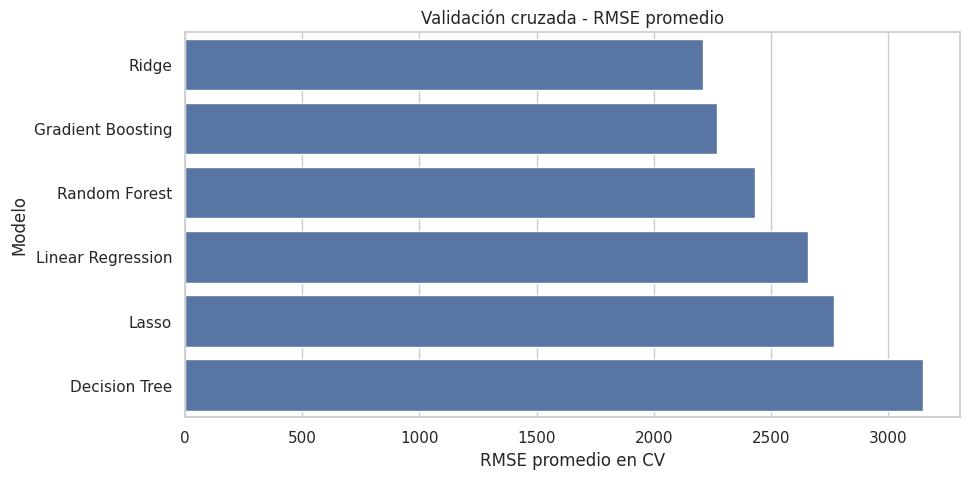

In [28]:
plt.figure(figsize=(10,5))
sns.barplot(data=cv_results_df, x="CV_RMSE_mean", y="Modelo")
plt.title("Validación cruzada - RMSE promedio")
plt.xlabel("RMSE promedio en CV")
plt.ylabel("Modelo")
plt.show()

## Resultados de validación cruzada

Los resultados de validación cruzada muestran que el modelo **Ridge** obtuvo el menor RMSE promedio, seguido de cerca por **Gradient Boosting** y **Random Forest**.

Este resultado es relevante porque difiere parcialmente de la evaluación inicial sobre el conjunto de testeo, donde Gradient Boosting había obtenido el mejor desempeño. Esto indica que, si bien Gradient Boosting funciona muy bien sobre la partición de testeo utilizada, Ridge presenta un rendimiento promedio más estable durante la validación cruzada.

Además, se observa que los modelos basados en árboles individuales, como **Decision Tree**, presentan un error promedio más alto y una mayor variabilidad entre folds. Esto sugiere una menor capacidad de generalización en comparación con modelos regularizados o modelos de ensamble.

A partir de estos resultados, los modelos más prometedores para continuar con la optimización son **Ridge**, por su estabilidad, y **Gradient Boosting**, por su buen desempeño inicial y capacidad para capturar relaciones no lineales.

## Selección del modelo para optimización

A partir de los resultados obtenidos en el entrenamiento inicial y en la validación cruzada, se seleccionó un modelo para aplicar optimización de hiperparámetros.

En la primera evaluación sobre el conjunto de testeo, el modelo con mejor desempeño fue **Gradient Boosting**, obteniendo el menor RMSE y el mayor R². Sin embargo, en la validación cruzada el modelo **Ridge** presentó el menor RMSE promedio, lo que indica una mayor estabilidad en las distintas particiones del conjunto de entrenamiento.

Dado que el objetivo del proyecto es construir un modelo predictivo capaz de capturar relaciones complejas entre las variables del automóvil y su precio, se decidió optimizar **Gradient Boosting Regressor**. Este modelo combina buen desempeño inicial con la capacidad de modelar relaciones no lineales e interacciones entre variables.

La optimización buscará encontrar una combinación de hiperparámetros que mejore el desempeño del modelo y reduzca el error de predicción.

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

grid_search_gb = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search_gb.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid_search_gb.best_params_)

print("\nMejor RMSE promedio en validación cruzada:")
print(-grid_search_gb.best_score_)

Mejores hiperparámetros:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Mejor RMSE promedio en validación cruzada:
2269.5644996299425


## Optimización mediante GridSearchCV

Se aplicó `GridSearchCV` sobre el modelo `GradientBoostingRegressor` para buscar la mejor combinación de hiperparámetros.

La búsqueda se realizó utilizando validación cruzada de 5 folds y tomando como métrica principal el RMSE, ya que esta métrica penaliza con mayor fuerza los errores grandes en la predicción del precio.

Los mejores hiperparámetros encontrados fueron:

- `learning_rate`: 0.1
- `max_depth`: 3
- `min_samples_leaf`: 1
- `min_samples_split`: 2
- `n_estimators`: 100

El mejor RMSE promedio obtenido en validación cruzada fue aproximadamente **2269.56**. Este resultado indica que, durante la validación cruzada, el modelo optimizado logró un error promedio cercano a 2270 unidades monetarias al predecir el precio de los automóviles.

La elección de `GradientBoostingRegressor` se justifica porque es un modelo basado en ensambles capaz de capturar relaciones no lineales entre las variables. Esto resulta especialmente relevante en este dataset, donde el análisis exploratorio mostró que el precio no depende de una única variable, sino de la combinación entre potencia, tamaño del motor, peso, dimensiones, marca y eficiencia de combustible.

Aunque `Ridge` presentó un desempeño competitivo en la validación cruzada inicial, se decidió optimizar `GradientBoostingRegressor` para evaluar si un modelo no lineal basado en ensambles podía mejorar la capacidad predictiva. Esta comparación permite analizar tanto modelos lineales regularizados como modelos más flexibles.

## Evaluación del modelo optimizado

Una vez finalizada la búsqueda de hiperparámetros, se evaluó el mejor modelo obtenido sobre el conjunto de testeo.

Esta etapa permite medir el desempeño del modelo sobre datos no vistos, es decir, registros que no fueron utilizados durante el entrenamiento ni durante la validación cruzada de `GridSearchCV`.

Para esta evaluación se utilizaron las mismas métricas empleadas en los modelos base: `MAE`, `RMSE` y `R²`.

In [30]:
best_gb_model = grid_search_gb.best_estimator_

y_pred_gb = best_gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_r2 = r2_score(y_test, y_pred_gb)

optimized_results = pd.DataFrame([{
    "Modelo": "Gradient Boosting Optimizado",
    "MAE": gb_mae,
    "RMSE": gb_rmse,
    "R2": gb_r2
}])

optimized_results

,Modelo,MAE,RMSE,R2
0,Gradient Boosting Optimizado,1554.631047,2443.985387,0.951179


El modelo `Gradient Boosting Optimizado` obtuvo un **MAE de aproximadamente 1554.63**, un **RMSE de aproximadamente 2443.99** y un **R² de 0.95** sobre el conjunto de testeo.

El valor de MAE indica que, en promedio, las predicciones del modelo se desvían alrededor de 1555 unidades monetarias respecto del precio real. Por su parte, el RMSE es mayor que el MAE, lo cual sugiere la presencia de algunos errores más grandes, probablemente asociados a vehículos de mayor precio o menos representados en el dataset.

El R² de 0.95 indica que el modelo logra explicar aproximadamente el 95% de la variabilidad del precio en el conjunto de testeo. Este resultado muestra un buen desempeño predictivo, aunque debe interpretarse con cautela debido al tamaño reducido del dataset.

## Comparación final de modelos

In [31]:
comparison_results = pd.concat([
    results_df,
    optimized_results
], ignore_index=True).sort_values(by="RMSE")

comparison_results

,Modelo,MAE,RMSE,R2
0,Gradient Boosting,1554.631047,2443.985387,0.951179
6,Gradient Boosting Optimizado,1554.631047,2443.985387,0.951179
1,Decision Tree,1829.695122,2849.080049,0.933654
2,Random Forest,1814.204711,2865.286915,0.932897
3,Lasso,1863.351532,2898.855029,0.931315
4,Linear Regression,1860.802757,2945.646399,0.929080
5,Ridge,1831.783157,2946.778956,0.929025


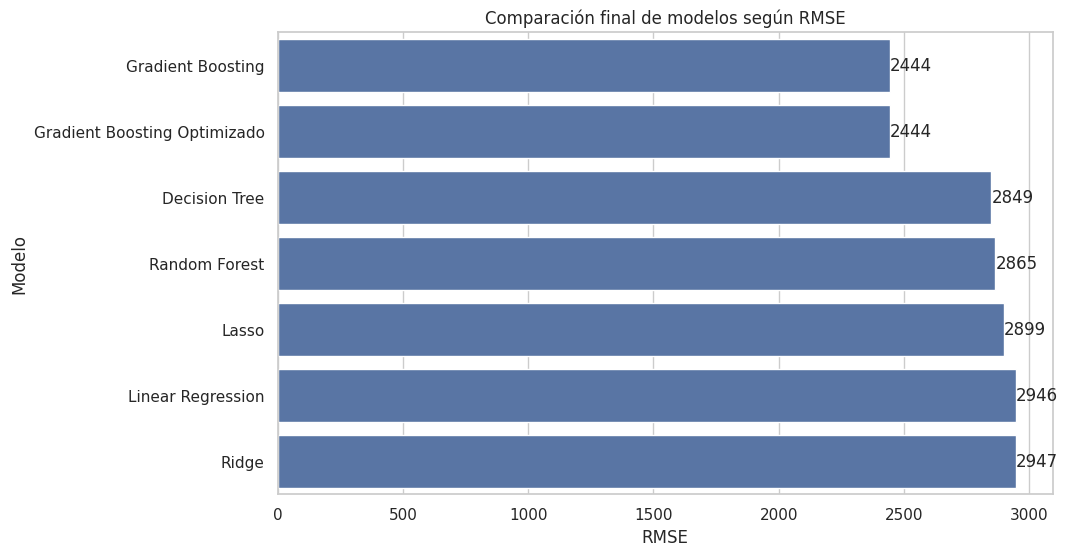

In [32]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=comparison_results,
    x="RMSE",
    y="Modelo"
)

plt.title("Comparación final de modelos según RMSE")
plt.xlabel("RMSE")
plt.ylabel("Modelo")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.show()

El gráfico de RMSE confirma que `Gradient Boosting` fue el modelo con menor error promedio. Dado que RMSE penaliza con mayor intensidad los errores grandes, este resultado es especialmente relevante en un problema de predicción de precios, donde equivocarse mucho en autos de alto valor puede tener un impacto importante.

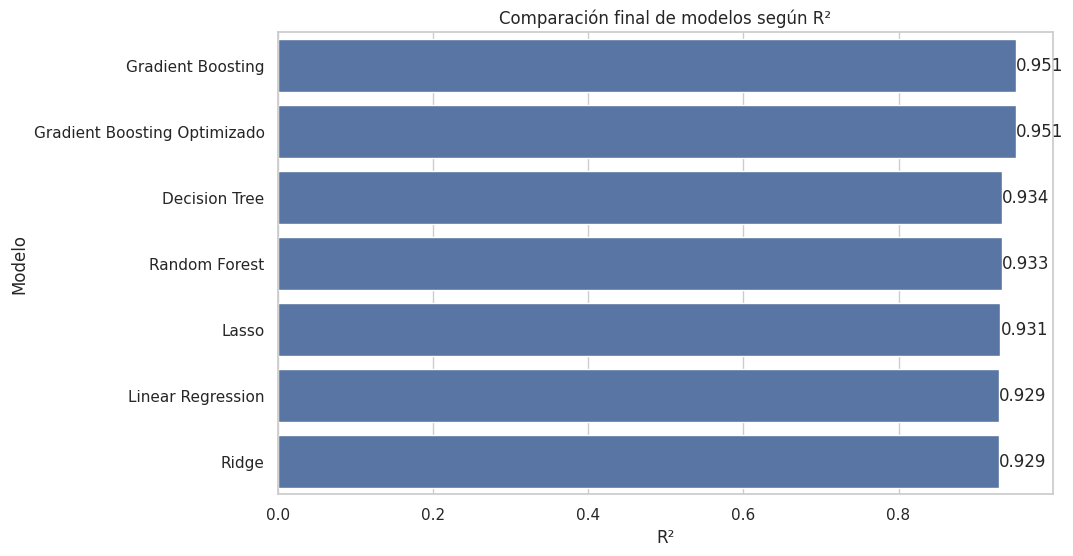

In [33]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=comparison_results.sort_values(by="R2", ascending=False),
    x="R2",
    y="Modelo"
)

plt.title("Comparación final de modelos según R²")
plt.xlabel("R²")
plt.ylabel("Modelo")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.show()

El gráfico de R² muestra que `Gradient Boosting` también fue el modelo con mayor capacidad explicativa, alcanzando un valor cercano a **0.95**. Esto significa que el modelo logra explicar aproximadamente el 95% de la variabilidad observada en el precio de los automóviles dentro del conjunto de testeo.

Se mantiene la fila del modelo optimizado para dejar evidencia del proceso de optimización requerido por la consigna, aunque sus métricas coincidan con el modelo base.

La comparación final muestra que el modelo con mejor desempeño fue `Gradient Boosting`, con un RMSE aproximado de **2443.99**, un MAE de **1554.63** y un R² de **0.951**.

El modelo `Gradient Boosting Optimizado` obtuvo exactamente los mismos resultados que el modelo base. Esto se debe a que los mejores hiperparámetros encontrados por `GridSearchCV` coinciden con la configuración utilizada inicialmente por el modelo. Por lo tanto, la optimización no generó una mejora adicional, pero sí permitió validar que esa combinación de hiperparámetros era adecuada dentro del espacio de búsqueda definido.

En segundo lugar se ubicaron modelos como `Decision Tree` y `Random Forest`, aunque con valores de RMSE superiores. Los modelos lineales y regularizados, como `Linear Regression`, `Ridge` y `Lasso`, también obtuvieron buenos valores de R², pero presentaron un error mayor en comparación con `Gradient Boosting`.

Dado que el objetivo principal es minimizar el error de predicción del precio, se selecciona `Gradient Boosting` como modelo final. Este modelo ofrece el menor RMSE y el mayor R² entre las alternativas evaluadas, lo que indica una mejor capacidad para capturar las relaciones entre las características del automóvil y su precio.

## Análisis de predicciones individuales

Además de evaluar el modelo mediante métricas agregadas, se compararon algunas predicciones individuales contra sus valores reales.

Este análisis permite observar casos concretos donde el modelo predice correctamente y casos donde el error es mayor. Para cada registro se calcula también el error absoluto, es decir, la diferencia en valor absoluto entre el precio real y el precio estimado por el modelo.

In [34]:
predictions_df = pd.DataFrame({
    "Precio real": y_test,
    "Precio predicho": y_pred_gb,
    "Error absoluto": abs(y_test - y_pred_gb)
})

predictions_df.head(10)

,Precio real,Precio predicho,Error absoluto
98,8249.0,7433.641688,815.358312
16,41315.0,31181.900937,10133.099063
31,6855.0,6326.931903,528.068097
162,9258.0,7821.895086,1436.104914
132,11850.0,13332.743120,1482.743120
118,5572.0,5923.674577,351.674577
72,35056.0,33718.967919,1337.032081
175,9988.0,10905.719220,917.719220
179,15998.0,17118.871854,1120.871854
48,35550.0,32361.757958,3188.242042


En la muestra de predicciones se observa que el modelo logra estimaciones cercanas para varios vehículos, con errores relativamente bajos en comparación con el precio real. Sin embargo, también aparecen casos con errores más elevados, especialmente en autos de mayor valor.

Esto es consistente con lo observado durante el análisis exploratorio: la mayoría de los vehículos se concentra en rangos de precio bajos y medios, mientras que los autos más caros aparecen con menor frecuencia. Al haber menos ejemplos de vehículos de alta gama, el modelo puede tener más dificultad para aprender esos patrones con la misma precisión.

## Comparación visual entre precios reales y predichos

Para complementar la tabla anterior, se construyó un gráfico de dispersión entre los precios reales y los precios predichos por el modelo.

La línea diagonal representa una predicción perfecta: cuanto más cerca se encuentran los puntos de esa línea, menor es el error del modelo.

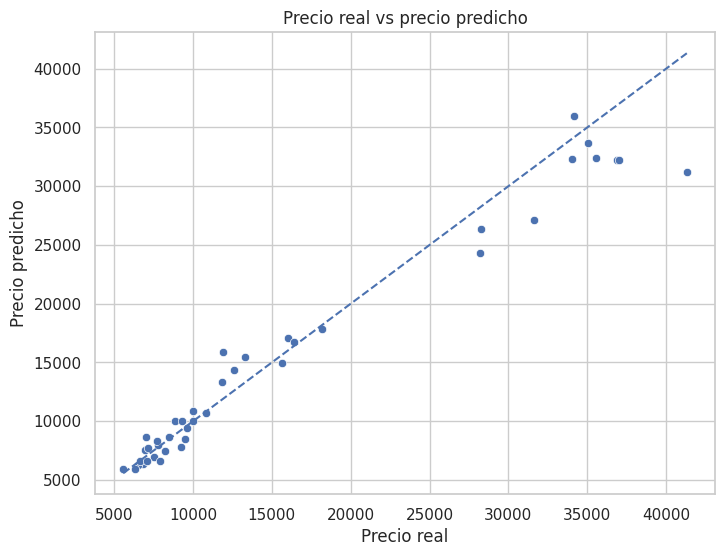

In [35]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=y_test, y=y_pred_gb)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--"
)

plt.title("Precio real vs precio predicho")
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")

plt.show()

El gráfico muestra que la mayoría de las predicciones se ubica cerca de la línea diagonal, lo que indica que el modelo captura correctamente la tendencia general del precio.

En los vehículos de menor y mediano valor, las predicciones se concentran con bastante proximidad respecto de los valores reales. En cambio, para algunos vehículos de precio elevado se observa una mayor dispersión y una tendencia a subestimar ciertos casos.

Este comportamiento puede explicarse por la distribución del dataset: los autos de mayor precio son menos frecuentes, por lo que el modelo cuenta con menos ejemplos para aprender sus patrones específicos. Aun así, la relación general entre valores reales y predichos es positiva y consistente con el buen desempeño observado en las métricas finales.

## Distribución del error absoluto

Para complementar las métricas globales, se analiza la distribución del error absoluto de las predicciones.

Esta visualización permite observar si la mayoría de los errores se concentra en valores bajos o si existen casos puntuales donde el modelo se equivoca de forma significativa.

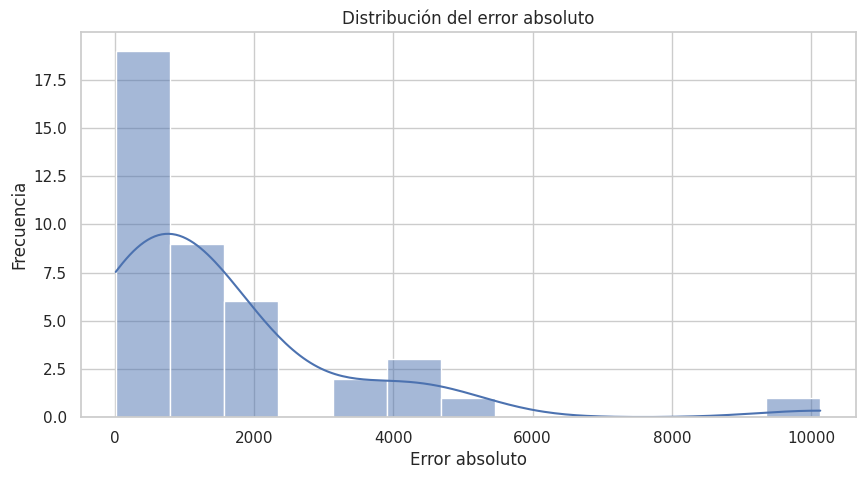

In [36]:
plt.figure(figsize=(10,5))

sns.histplot(predictions_df["Error absoluto"], kde=True)

plt.title("Distribución del error absoluto")
plt.xlabel("Error absoluto")
plt.ylabel("Frecuencia")

plt.show()

La distribución del error absoluto muestra que la mayoría de las predicciones presentan errores relativamente bajos, concentrados principalmente por debajo de las 2.000 unidades monetarias.

Sin embargo, también se observan algunos errores altos, incluyendo casos cercanos o superiores a 4.000 y un valor extremo próximo a 10.000. Esto confirma lo observado en el gráfico de precios reales versus predichos: el modelo tiene buen desempeño general, pero puede presentar mayores dificultades en ciertos vehículos de precio elevado o poco representados en el dataset.

Este comportamiento también explica por qué el RMSE es mayor que el MAE, ya que el RMSE penaliza con más fuerza los errores grandes.

## Análisis de los mayores errores

Para identificar los casos donde el modelo tuvo más dificultad, se ordenaron las predicciones según el error absoluto de mayor a menor.

Este análisis permite detectar si los errores más grandes se concentran en algún tipo particular de vehículo o rango de precio.

In [37]:
predictions_df.sort_values(by="Error absoluto", ascending=False).head(10)

,Precio real,Precio predicho,Error absoluto
16,41315.0,31181.900937,10133.099063
128,37028.0,32232.042645,4795.957355
17,36880.0,32257.985617,4622.014383
70,31600.0,27127.790182,4472.209818
107,11900.0,15865.046134,3965.046134
69,28176.0,24328.860728,3847.139272
48,35550.0,32361.757958,3188.242042
191,13295.0,15504.323021,2209.323021
68,28248.0,26321.597627,1926.402373
71,34184.0,35969.491217,1785.491217


Los mayores errores se observan principalmente en vehículos de precio alto, varios de ellos por encima de las 28.000 unidades monetarias.

El caso con mayor error corresponde a un vehículo con precio real de **41.315** y precio predicho de aproximadamente **31.181**, generando un error absoluto superior a **10.000**. Esto confirma que el modelo tiende a tener más dificultad en los autos de mayor valor, probablemente porque estos casos son menos frecuentes dentro del dataset.

Aun así, estos errores representan casos puntuales. La mayoría de las predicciones presenta errores considerablemente menores, como se observó en la distribución del error absoluto.

## Importancia de variables del modelo

Para interpretar el comportamiento del modelo final, se analizó la importancia de las variables utilizadas por `Gradient Boosting`.

Este análisis permite identificar qué atributos tuvieron mayor peso en la predicción del precio de los automóviles.

In [38]:
feature_names_num = numeric_features.tolist()

feature_names_cat = best_gb_model.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .named_steps["encoder"] \
    .get_feature_names_out(categorical_features)

feature_names = np.concatenate([feature_names_num, feature_names_cat])

importances = best_gb_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": importances
}).sort_values(by="Importancia", ascending=False)

feature_importance_df.head(15)

,Variable,Importancia
6,curb-weight,0.411730
7,engine-size,0.277788
11,horsepower,0.080632
4,width,0.042876
13,city-mpg,0.038017
14,highway-mpg,0.034020
3,length,0.027407
2,wheel-base,0.017810
21,make_bmw,0.007985
17,engine_efficiency,0.006777


El modelo identificó como variables más importantes a `curb-weight`, `engine-size` y `horsepower`, lo cual coincide con los patrones observados durante el EDA.

Esto refuerza la conclusión de que el precio está fuertemente asociado a características técnicas del vehículo, especialmente peso, tamaño del motor y potencia. También aparecen variables de consumo y dimensiones, como `city-mpg`, `highway-mpg` y `width`, que aportan información complementaria para la predicción.

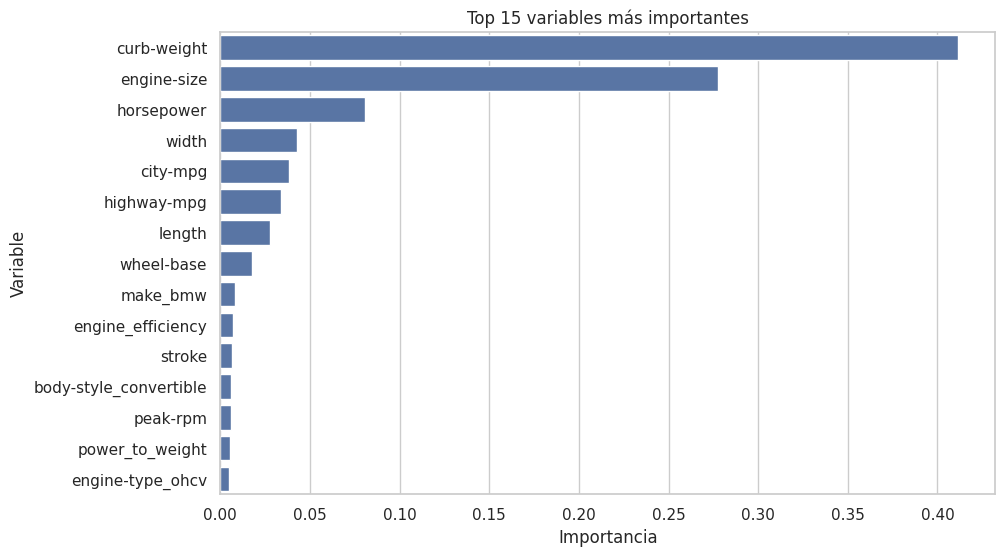

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_df.head(15),
    x="Importancia",
    y="Variable"
)

plt.title("Top 15 variables más importantes")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.show()

El gráfico confirma que `curb-weight` es la variable con mayor importancia para el modelo, seguida por `engine-size` y `horsepower`.

Esto indica que el precio está explicado principalmente por atributos técnicos asociados al tamaño, peso y potencia del vehículo. El resultado es consistente con el EDA, donde estas mismas variables mostraron alta correlación con `price`.

Las variables categóricas aparecen con menor peso relativo, aunque algunas como `make_bmw` y `body-style_convertible` aportan información adicional sobre segmentos de mayor valor.

## Selección final del modelo

A partir de la comparación final, se selecciona `Gradient Boosting` como modelo final, ya que obtuvo el mejor desempeño general sobre el conjunto de testeo.

El modelo alcanzó un **MAE de 1554.63**, un **RMSE de 2443.99** y un **R² de 0.951**. Esto indica que logra explicar aproximadamente el 95% de la variabilidad del precio y mantiene el menor error entre los modelos evaluados.

La optimización mediante `GridSearchCV` no mejoró las métricas del modelo base, ya que los mejores hiperparámetros encontrados coincidieron con la configuración inicial. Aun así, el proceso permitió validar que esa configuración era adecuada dentro del espacio de búsqueda definido.

## Conclusiones finales

El objetivo del proyecto fue predecir el precio de automóviles a partir de características técnicas y comerciales. Para esto, se realizó limpieza de datos, análisis exploratorio, ingeniería de atributos, preprocesamiento y entrenamiento de distintos modelos de regresión.

Durante el EDA se observó que `price` tiene una distribución asimétrica, con mayor concentración de autos en rangos bajos y medios, y pocos vehículos de precio elevado. También se identificó una fuerte relación entre el precio y variables como `engine-size`, `curb-weight`, `horsepower`, `width` y `length`.

El modelo final confirmó estos patrones: las variables más importantes fueron `curb-weight`, `engine-size` y `horsepower`. Esto refuerza que el precio está explicado principalmente por atributos asociados al peso, tamaño del motor y potencia del vehículo.

En términos predictivos, `Gradient Boosting` fue el modelo con mejor desempeño, alcanzando un R² de 0.951 y un RMSE de 2443.99. El modelo funcionó especialmente bien en autos de precio bajo y medio, aunque presentó mayores errores en algunos vehículos de alto valor.

## Limitaciones y próximos pasos

La principal limitación del proyecto es el tamaño reducido del dataset, con poco más de 200 registros. Esto puede afectar la capacidad del modelo para generalizar, especialmente en autos de gama alta, que aparecen con menor frecuencia.

Además, el dataset no incluye variables relevantes para una valuación real actual, como año del vehículo, kilometraje, estado general, país, inflación, demanda de mercado o historial de mantenimiento.

Como próximos pasos, sería recomendable trabajar con un dataset más grande y actualizado, incorporar variables externas y probar modelos adicionales como XGBoost o LightGBM. También podría aplicarse SHAP para profundizar la interpretación del impacto de cada variable sobre las predicciones.

## Cierre Ejecutivo

El análisis permitió construir un modelo de Machine Learning capaz de estimar el precio de automóviles con buen desempeño predictivo.

El modelo seleccionado fue `Gradient Boosting`, que obtuvo un **R² de 0.951** y un **MAE de 1554.63** sobre el conjunto de testeo. Las variables más relevantes fueron `curb-weight`, `engine-size` y `horsepower`, lo que indica que el precio está fuertemente asociado a características técnicas del vehículo.

Desde una perspectiva de negocio, este tipo de modelo puede ser útil como apoyo para procesos de pricing, valuación inicial de vehículos y análisis comparativo de mercado. Sin embargo, para un uso productivo sería necesario ampliar el volumen de datos e incorporar variables más actualizadas del contexto real.